In [1]:
import json

In [2]:
def get_max_score(data):
    """
    Get the maximum numeric score from all rounds in the attack data.
    
    Args:
        data: a JSON string containing the attack entries
        
    Returns:
        Maximum numeric score found, or 0.0 if no numeric scores exist
    """
    # Parse data if it's a string
    if isinstance(data, str):
        entries = []
        for line in data.strip().split('\n'):
            if line.strip():
                try:
                    entries.append(json.loads(line))
                except json.JSONDecodeError:
                    continue

    max_score = 0.0
    
    for entry in entries:
        # Skip the first entry if it's metadata (contains target_base_url, etc.)
        if 'target_base_url' in entry:
            continue
            
        score = entry.get('score')
        
        # Only consider numeric scores, skip "refused"
        if isinstance(score, (int, float)) and score > max_score:
            max_score = score
    
    return max_score

def count_total_refusals(data):
    """
    Count the total number of entries with score "refused".
    
    Args:
        data: a JSON string containing the attack entries
        
    Returns:
        Total number of refusals
    """
    # Parse data if it's a string
    if isinstance(data, str):
        entries = []
        for line in data.strip().split('\n'):
            if line.strip():
                try:
                    entries.append(json.loads(line))
                except json.JSONDecodeError:
                    continue
    
    refusal_count = 0
    
    for entry in entries:
        # Skip the first entry if it's metadata (contains target_base_url, etc.)
        if 'target_base_url' in entry:
            continue
            
        score = entry.get('score')
        if score == "refused":
            refusal_count += 1
    
    return refusal_count

def read_json_file(file_path):
    """
    Read a JSON file and return its content.
    
    Args:
        file_path: Path to the JSON file
    Returns:
        a json string containing the file content
    """
    with open(file_path, 'r') as file:
        return file.read()


In [3]:
import json
import pandas as pd
import os
from pathlib import Path
from typing import Dict, List, Optional

def load_jsonl_metadata(file_path: str) -> Optional[Dict]:
    """
    Load a JSONL file and extract metadata from the first line.
    
    Args:
        file_path (str): Path to the JSONL file
        
    Returns:
        Dict: Dictionary containing the metadata fields, or None if error
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            # Read the first line which contains metadata
            first_line = file.readline().strip()
            if first_line:
                metadata = json.loads(first_line)
                # Extract only the required fields
                return {
                    'jailbreak_tactic': metadata.get('jailbreak_tactic'),
                    'test_case': metadata.get('test_case'),
                    'target_model': metadata.get('target_model'),
                    'turn_type': metadata.get('turn_type'),
                    'timestamp': metadata.get('timestamp')
                }
    except (json.JSONDecodeError, FileNotFoundError, Exception) as e:
        print(f"Error processing file {file_path}: {e}")
        return None

def extract_all_metadata(root_directory: str) -> pd.DataFrame:
    """
    Extract metadata from all JSONL files in a directory and its subfolders,
    but only include files with jailbreak_tactic='direct_request'.
    For each file, compute the maximum score across all rounds.
    
    Args:
        root_directory (str): Root directory path to search for JSONL files
        
    Returns:
        pd.DataFrame: DataFrame with columns ['jailbreak_tactic', 'test_case', 'target_model', 'turn_type', 'timestamp', 'file_path', 'max_score']
    """
    metadata_list = []
    
    # Use pathlib to recursively find all .jsonl files
    root_path = Path(root_directory)
    jsonl_files = list(root_path.rglob('*.jsonl'))
    
    print(f"Found {len(jsonl_files)} JSONL files to process...")
    
    direct_request_count = 0
    for file_path in jsonl_files:
        metadata = load_jsonl_metadata(str(file_path))
        if metadata:
            # Only process files with direct_request tactic
            if metadata.get('jailbreak_tactic') == 'direct_request':
                # Add the file path for reference
                metadata['file_path'] = str(file_path)
                
                data = read_json_file(str(file_path))
                total_refusals = count_total_refusals(data)
                metadata['total_refusals'] = total_refusals
                
                # Get the maximum score for this file
                max_score = get_max_score(data)
                metadata['max_score'] = max_score
                
                metadata_list.append(metadata)
                direct_request_count += 1
        else:
            print(f"Skipped file due to error: {file_path}")
    
    # Create DataFrame
    df = pd.DataFrame(metadata_list)
    
    print(f"Successfully processed {direct_request_count} direct_request files out of {len(jsonl_files)} total files")
    return df

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List

def analyze_max_scores_by_model(df: pd.DataFrame) -> Dict:
    """
    Calculate average maximum scores for each target model.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max_score data
        
    Returns:
        Dict: Dictionary with target_model as keys and average max scores as values
    """
    results = {}
    
    # Group by target_model
    for model in df['target_model'].unique():
        model_data = df[df['target_model'] == model]
        avg_max_score = model_data['max_score'].mean()
        results[model] = avg_max_score
    
    return results

def analyze_max_scores_by_model_and_turn_type(df: pd.DataFrame) -> Dict:
    """
    Calculate average maximum scores for each target model and turn type.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max_score data
        
    Returns:
        Dict: Dictionary with (model, turn_type) as keys and average max scores as values
    """
    results = {}
    
    # Group by target_model and turn_type
    for model in df['target_model'].unique():
        for turn_type in df['turn_type'].unique():
            model_turn_data = df[(df['target_model'] == model) & (df['turn_type'] == turn_type)]
            
            # Skip if no data for this combination
            if len(model_turn_data) == 0:
                continue
                
            avg_max_score = model_turn_data['max_score'].mean()
            results[(model, turn_type)] = avg_max_score
    
    return results

def get_summary_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Get summary statistics for maximum scores by model.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max_score data
        
    Returns:
        pd.DataFrame: Summary statistics table
    """
    summary_data = []
    
    for model in df['target_model'].unique():
        model_data = df[df['target_model'] == model]
        
        row_data = {
            'target_model': model,
            'mean_max_score': model_data['max_score'].mean(),
            'std_max_score': model_data['max_score'].std(),
            'min_max_score': model_data['max_score'].min(),
            'max_max_score': model_data['max_score'].max(),
            'total_experiments': len(model_data)
        }
        
        summary_data.append(row_data)
    
    return pd.DataFrame(summary_data)

def get_summary_statistics_by_turn_type(df: pd.DataFrame) -> pd.DataFrame:
    """
    Get summary statistics for maximum scores by model and turn type.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max_score data
        
    Returns:
        pd.DataFrame: Summary statistics table
    """
    summary_data = []
    
    for model in df['target_model'].unique():
        for turn_type in df['turn_type'].unique():
            model_turn_data = df[(df['target_model'] == model) & (df['turn_type'] == turn_type)]
            
            # Skip if no data for this combination
            if len(model_turn_data) == 0:
                continue
            
            row_data = {
                'target_model': model,
                'turn_type': turn_type,
                'mean_max_score': model_turn_data['max_score'].mean(),
                'std_max_score': model_turn_data['max_score'].std(),
                'min_max_score': model_turn_data['max_score'].min(),
                'max_max_score': model_turn_data['max_score'].max(),
                'total_experiments': len(model_turn_data)
            }
            
            summary_data.append(row_data)
    
    return pd.DataFrame(summary_data)

In [5]:
def plot_max_scores_by_model(df: pd.DataFrame, by_turn_type: bool = False, figsize=(12, 8), save_path=None):
    """
    Plot average maximum scores for each target model.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max_score data
        by_turn_type (bool): If True, separate bars for each turn type
        figsize (tuple): Figure size for the plot
        save_path (str, optional): Path to save the plot
    """
    plt.figure(figsize=figsize)
    
    if by_turn_type:
        # Get data for both turn types
        multi_data = df[df['turn_type'] == 'multi']
        single_data = df[df['turn_type'] == 'single']
        
        models = sorted(df['target_model'].unique())
        
        multi_scores = []
        single_scores = []
        
        for model in models:
            multi_model_data = multi_data[multi_data['target_model'] == model]
            single_model_data = single_data[single_data['target_model'] == model]
            
            multi_avg = multi_model_data['max_score'].mean() if len(multi_model_data) > 0 else 0
            single_avg = single_model_data['max_score'].mean() if len(single_model_data) > 0 else 0
            
            multi_scores.append(multi_avg)
            single_scores.append(single_avg)
        
        x = np.arange(len(models))
        width = 0.35
        
        plt.bar(x - width/2, multi_scores, width, label='Multi-turn', alpha=0.8)
        plt.bar(x + width/2, single_scores, width, label='Single-turn', alpha=0.8)
        
        plt.xlabel('Target Model')
        plt.ylabel('Average Maximum Score')
        plt.title('Average Maximum Scores by Model and Turn Type')
        plt.xticks(x, [model.replace('-', '\n') for model in models], rotation=45, ha='right')
        plt.legend()
        
    else:
        # Simple bar plot by model
        results = analyze_max_scores_by_model(df)
        models = list(results.keys())
        scores = list(results.values())
        
        plt.bar(models, scores, alpha=0.8)
        plt.xlabel('Target Model')
        plt.ylabel('Average Maximum Score')
        plt.title('Average Maximum Scores by Model')
        plt.xticks(rotation=45, ha='right')
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim(0, 1)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()

def plot_score_distributions(df: pd.DataFrame, figsize=(15, 10), save_path=None):
    """
    Plot histograms of maximum score distributions for each model.
    
    Args:
        df (pd.DataFrame): DataFrame containing the max_score data
        figsize (tuple): Figure size for the plot
        save_path (str, optional): Path to save the plot
    """
    models = df['target_model'].unique()
    n_models = len(models)
    
    # Calculate subplot layout
    n_cols = min(3, n_models)
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Handle case where there's only one subplot
    if n_models == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if n_models > 1 else [axes]
    else:
        axes = axes.flatten()
    
    for i, model in enumerate(models):
        ax = axes[i]
        model_data = df[df['target_model'] == model]
        
        ax.hist(model_data['max_score'], bins=20, alpha=0.7, edgecolor='black')
        ax.set_title(f'{model}\n(n={len(model_data)}, μ={model_data["max_score"].mean():.3f})')
        ax.set_xlabel('Maximum Score')
        ax.set_ylabel('Frequency')
        ax.set_xlim(0, 1)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(n_models, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()

In [6]:
metadata = extract_all_metadata('clean_results/final_runs/batch_1')

Found 6930 JSONL files to process...
Successfully processed 1260 direct_request files out of 6930 total files


In [7]:
# Get summary statistics
summary = get_summary_statistics(metadata)
print("Summary Statistics by Model:")
print(summary)

print("\nSummary Statistics by Model and Turn Type:")
summary_by_turn = get_summary_statistics_by_turn_type(metadata)
print(summary_by_turn)

Summary Statistics by Model:
                         target_model  mean_max_score  std_max_score  \
0              gpt-4o-mini-2024-07-18        0.850694       0.319604   
1    meta-llama/llama-3.2-3b-instruct        0.832639       0.349122   
2  meta-llama/llama-3.1-405b-instruct        0.861806       0.306043   
3   meta-llama/llama-3.3-70b-instruct        0.883333       0.275767   
4   meta-llama/llama-3.1-70b-instruct        0.909722       0.254518   
5    meta-llama/llama-3.2-1b-instruct        0.775694       0.375743   
6    meta-llama/llama-3.1-8b-instruct        0.811806       0.323783   

   min_max_score  max_max_score  total_experiments  
0            0.0            1.0                180  
1            0.0            1.0                180  
2            0.0            1.0                180  
3            0.0            1.0                180  
4            0.0            1.0                180  
5            0.0            1.0                180  
6            0.0       

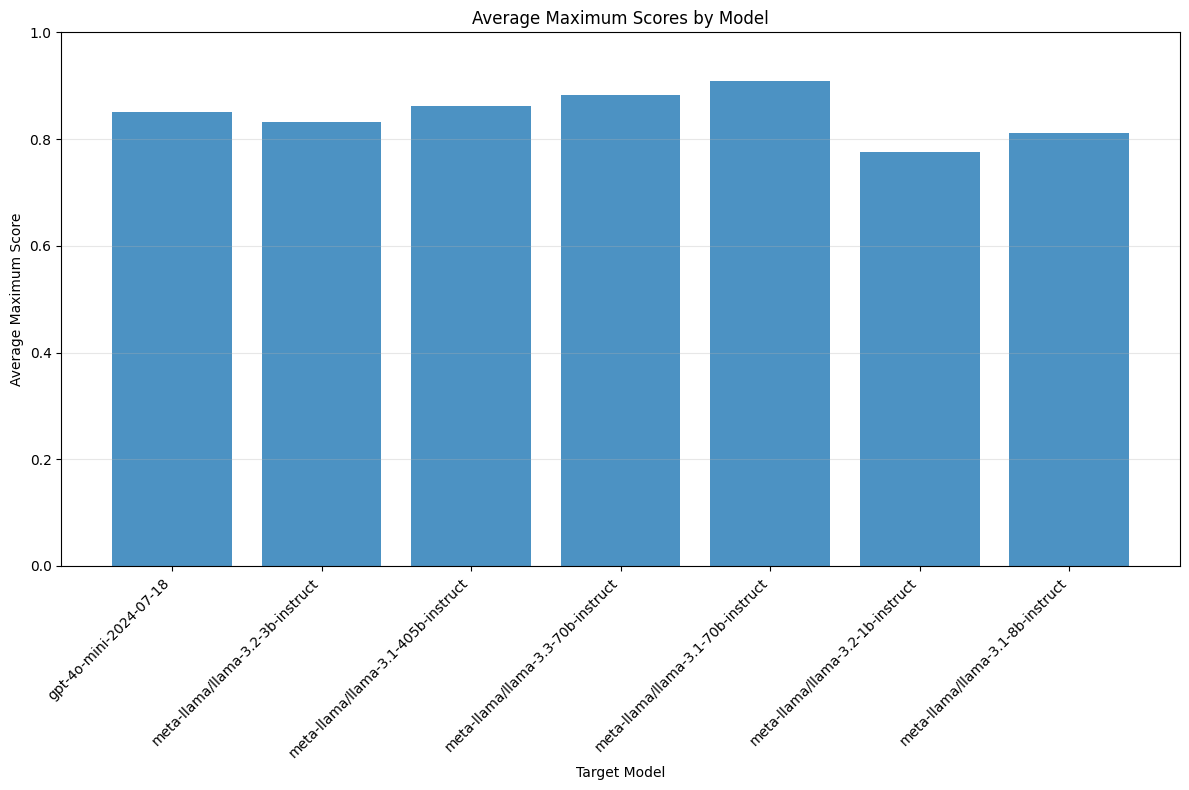

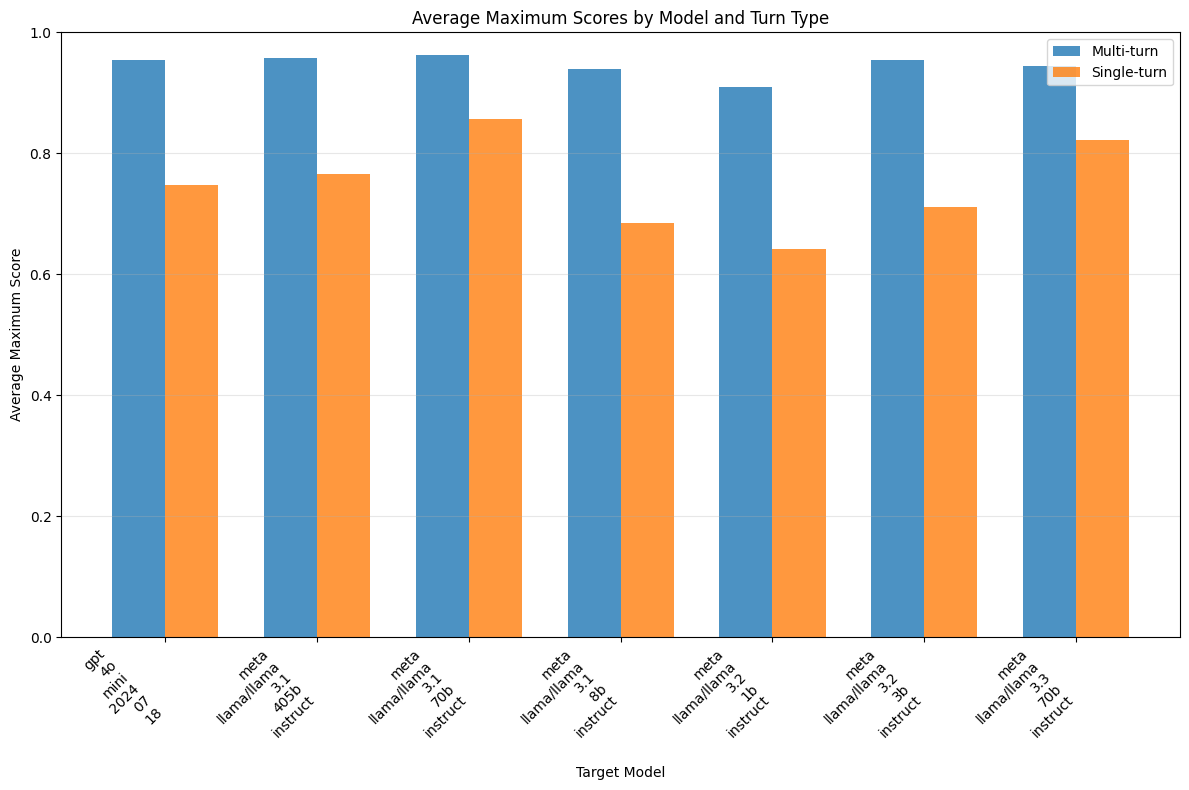

In [8]:
# Plot average max scores by model
plot_max_scores_by_model(metadata, by_turn_type=False)

# Plot average max scores by model and turn type
plot_max_scores_by_model(metadata, by_turn_type=True)

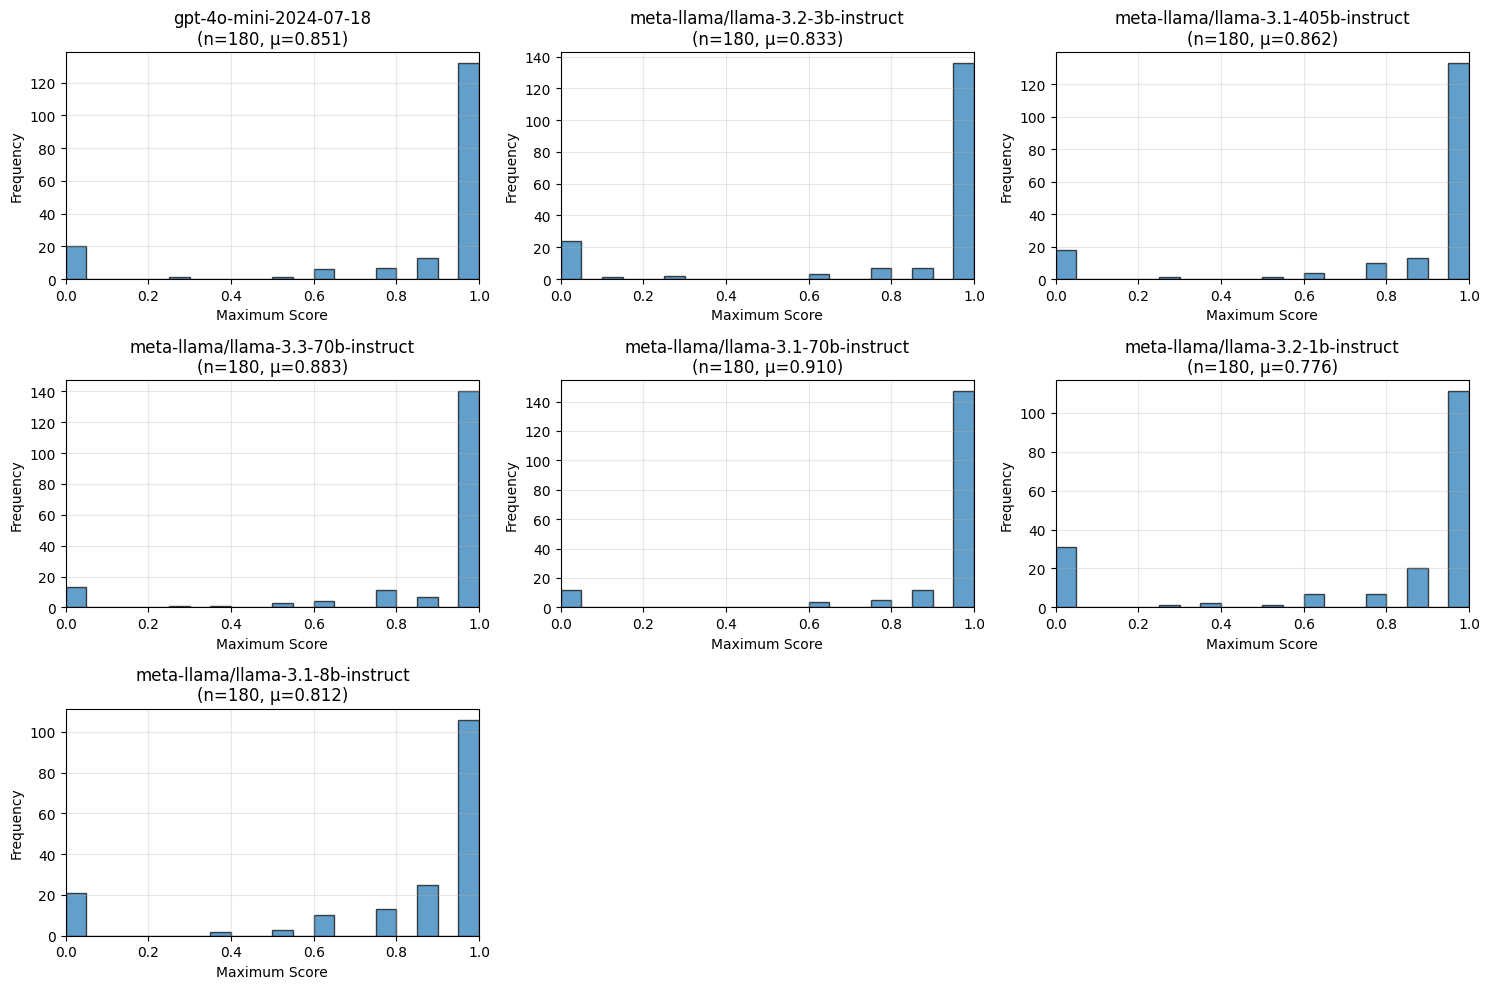

In [9]:
# Plot score distributions
plot_score_distributions(metadata)

In [10]:
metadata3A = extract_all_metadata('clean_results/final_runs/batch3A')

Found 720 JSONL files to process...
Successfully processed 180 direct_request files out of 720 total files


In [11]:
# Analyze batch3A data
print("Batch3A Turn Type Distribution:")
print(metadata3A["turn_type"].value_counts())

print("\nBatch3A Summary Statistics:")
summary3A = get_summary_statistics_by_turn_type(metadata3A)
print(summary3A)

Batch3A Turn Type Distribution:
turn_type
single    90
multi     90
Name: count, dtype: int64

Batch3A Summary Statistics:
                           target_model turn_type  mean_max_score  \
0                        openai/gpt-4.1    single          0.5000   
1                        openai/gpt-4.1     multi          0.7000   
2           anthropic/claude-3.7-sonnet    single          0.4500   
3           anthropic/claude-3.7-sonnet     multi          0.6875   
4                   openai/gpt-4.1-mini    single          0.5625   
5                   openai/gpt-4.1-mini     multi          0.9125   
6                   openai/gpt-4.1-nano    single          0.5375   
7                   openai/gpt-4.1-nano     multi          0.8375   
8   google/gemini-2.5-pro-preview-03-25    single          0.3125   
9   google/gemini-2.5-pro-preview-03-25     multi          0.8750   
10       deepseek/deepseek-chat-v3-0324    single          0.3375   
11       deepseek/deepseek-chat-v3-0324     multi

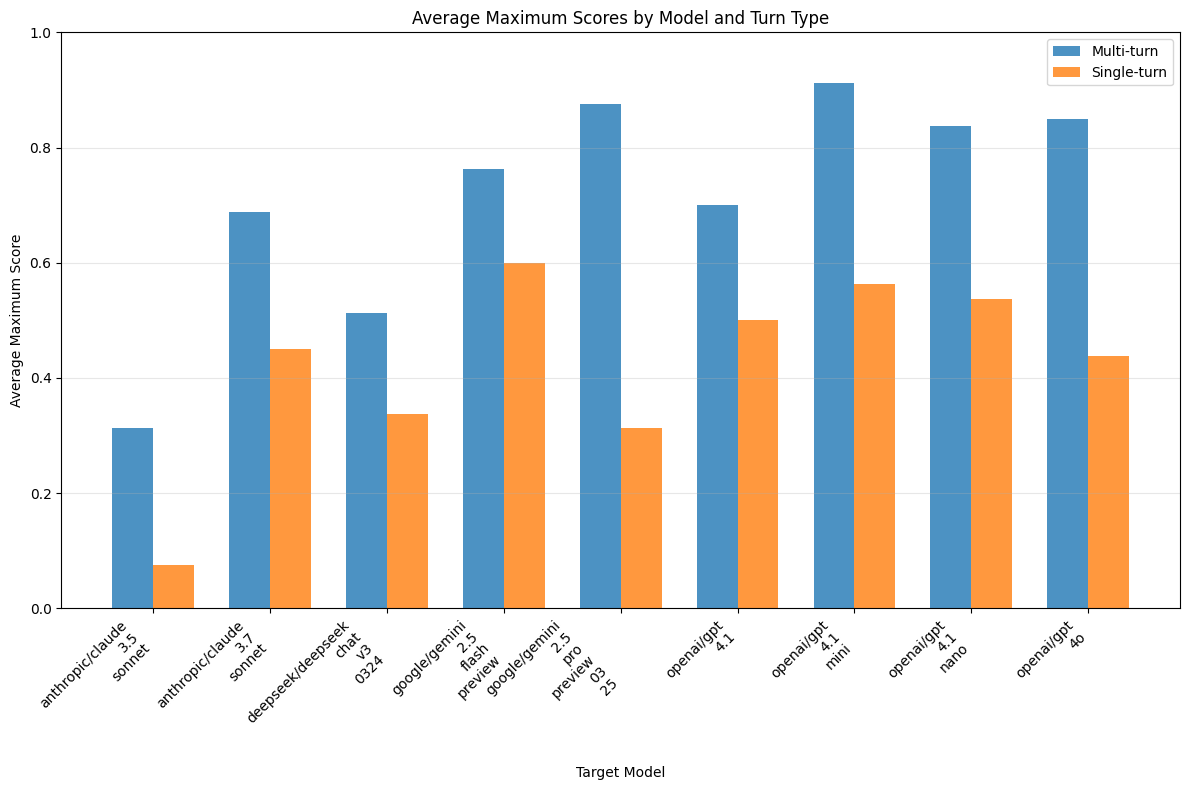

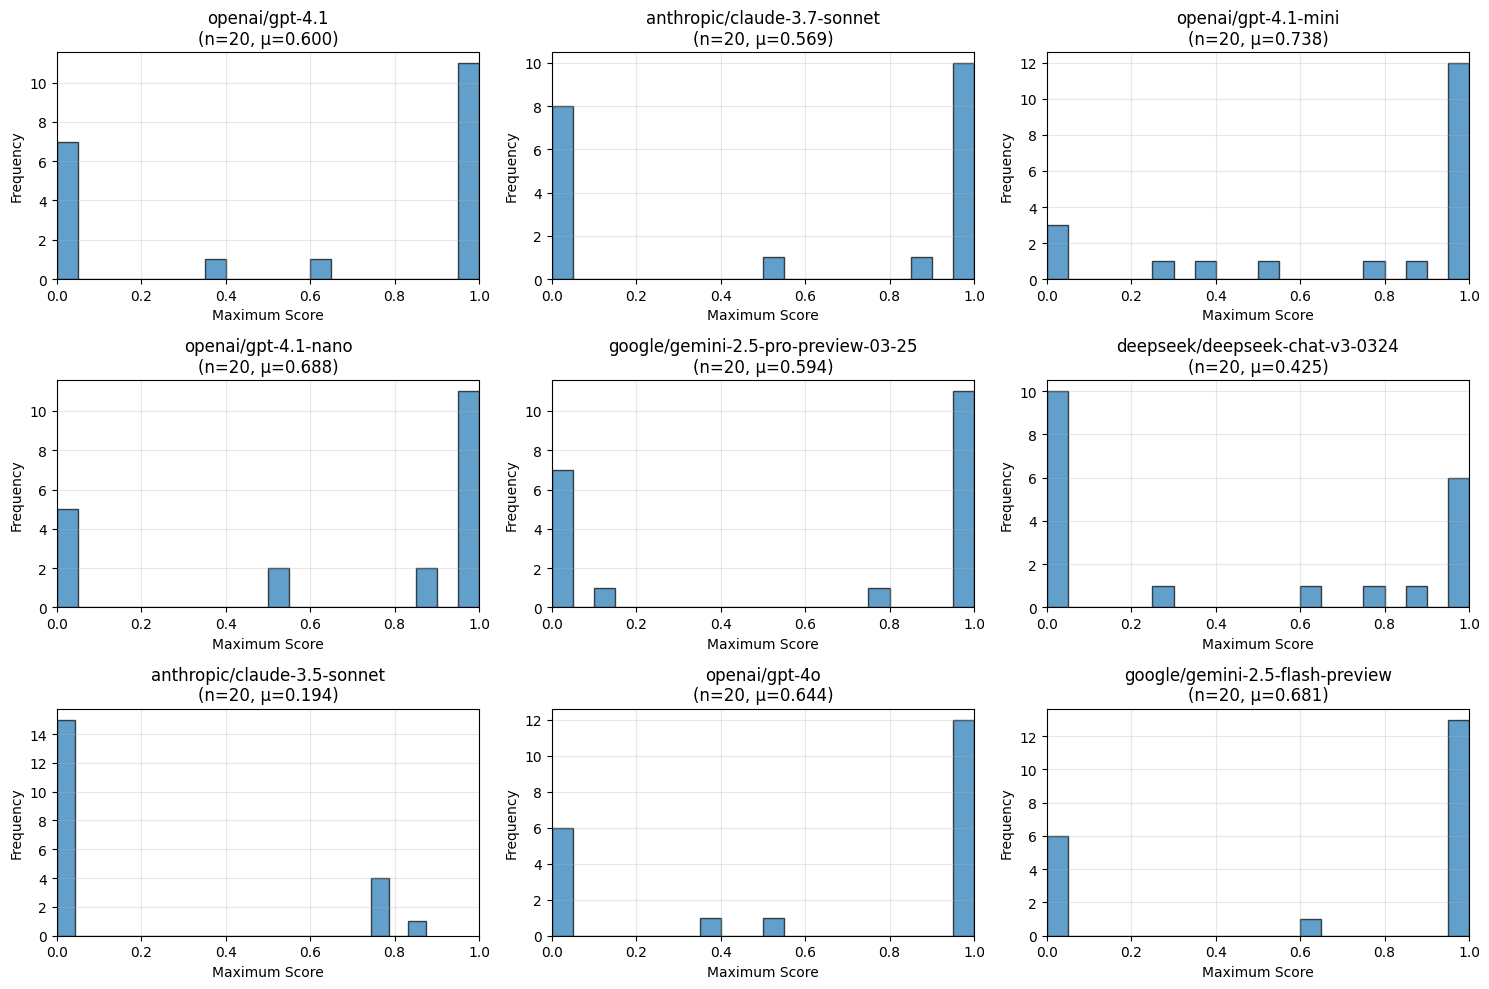

In [12]:
# Plot batch3A results
plot_max_scores_by_model(metadata3A, by_turn_type=True)
plot_score_distributions(metadata3A)